# Notebook 3A — Uncertainty for K-Nearest Neighbors

*Day 5b · Student A · read uncertainty out of your neighbours, calibrate it, and find where it still strains.*

In [1]:
# ======================================================================================
# Setup — run this first (you don't need to read it closely).
# It imports a few libraries, sets a shared plot style, and defines the helper functions used
# throughout the notebook (load_data, the plot helpers, the metric helpers, ...).  These are the
# SAME helpers in every notebook, so your results line up with your teammates'.  If a later cell
# says a helper is "not defined", you probably skipped this cell — run it, then carry on.
# ======================================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------------------
# Paths — resolved so the notebooks work whether they're run from the materials folder or
# from solutions/ .  Outputs and figures always land in the materials root.
# ----------------------------------------------------------------------------------------
def _materials_root():
    """Folder that contains data/ ; searched upward from the working directory."""
    here = os.path.abspath(os.getcwd())
    for d in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        if os.path.isdir(os.path.join(d, "data")):
            return d
    return here

ROOT = _materials_root()
DATA_DIR = os.path.join(ROOT, "data")
OUTPUTS_DIR = os.path.join(ROOT, "outputs")
FIGURES_DIR = os.path.join(ROOT, "figures")
MODELS_DIR = os.path.join(ROOT, "models")     # fitted models saved to disk (experiment tracking)
for _d in (DATA_DIR, OUTPUTS_DIR, FIGURES_DIR, MODELS_DIR):
    os.makedirs(_d, exist_ok=True)

# Module-level cache of the reconstruction basis (set by load_data; used by reconstruct_spectrum).
_RECON = {"wavelength": None, "basis": None, "is_mock": True, "Xerr": None}
_RAW_CACHE = {}   # path -> full arrays, so repeated load_data() calls don't re-read the file

# Default working-set size.  The real catalog is ~200k stars; we train on a fast deterministic
# subsample by default so in-class fits stay quick AND every notebook sees the SAME stars (which
# keeps the NB2->NB3->NB4 saved-prediction hand-off aligned).  Pass n=None to use the WHOLE
# high-quality catalog (the "does more data help?" / label-transfer-at-scale exercise).
DEFAULT_N = 30000

# Canonical label columns.  The modelling track predicts [Fe/H]; Teff & logg are explored and
# used as the axes for residual / coverage maps.  alpha/age/dist are extra "explore" labels.
LABEL_COLS = ["Teff", "logg", "FeH", "alpha", "age", "dist"]
PRETTY = {"Teff": r"$T_\mathrm{eff}$ [K]", "logg": r"$\log g$ [dex]",
          "FeH": r"[Fe/H] [dex]", "alpha": r"[$\alpha$/M] [dex]",
          "age": "age [Gyr]", "dist": "distance [pc]"}


# ========================================================================================
# Plot style
# ========================================================================================
def set_plot_style():
    """Consistent, readable matplotlib defaults.  Called once in setup."""
    plt.rcParams.update({
        "figure.figsize": (6.4, 4.4), "figure.dpi": 110, "savefig.dpi": 150,
        "savefig.bbox": "tight", "font.size": 12, "axes.titlesize": 13,
        "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.25,
        "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
        "legend.frameon": False, "legend.fontsize": 11, "lines.linewidth": 2.0,
        "scatter.edgecolors": "none", "image.cmap": "viridis",
    })

# A small colour-blind-friendly palette used across the materials for named series.
COLORS = {"linear": "#888888", "knn": "#0072B2", "rf": "#009E73",
          "nn": "#D55E00", "native": "#0072B2", "conformal": "#D55E00",
          "truth": "#222222", "accent": "#CC79A7"}


# ========================================================================================
# Data loading  (the mock generator lives here so the shipped npz and the on-the-fly
# fallback are guaranteed identical)
# ========================================================================================
_C2_NM = 1.438777e7  # second radiation constant hc/k in nm*K


def _build_basis(wave_min=336.0, wave_max=1020.0, n_wave=343, n_bp=55, n_rp=55):
    """Smooth windowed-cosine modes per band, orthonormalised.  Low modes are broad
    (continuum), high modes wiggly (fine structure).  reconstruct = B @ coeff."""
    wave = np.linspace(wave_min, wave_max, n_wave)
    cols = []
    def band(lo, hi, n_modes):
        x = (wave - lo) / (hi - lo)
        win = np.where((x >= 0) & (x <= 1), np.sin(np.clip(x, 0, 1) * np.pi) ** 0.5, 0.0)
        for j in range(n_modes):
            cols.append(np.cos(j * np.pi * np.clip(x, 0, 1)) * win)
    band(wave_min, 690.0, n_bp)
    band(630.0, wave_max, n_rp)
    Q, _ = np.linalg.qr(np.column_stack(cols))
    return wave, Q[:, :n_bp + n_rp]


def _synthesize_mock(n=50000, seed=42):
    """
    # MOCK DATA — swap for the real Zenodo loader.
    Physically-motivated synthetic stand-in for the Laroche & Speagle APOGEE x Gaia-XP
    cross-match.  Returns the same dict that the shipped npz stores.  See the build spec
    and _build/make_mock_dataset.py for the full rationale.  In one sentence: a Planck
    continuum sets Teff; Balmer lines reinforce Teff; gravity-sensitive molecular bands
    carry log g; SHALLOW metal lines (suppressed at high Teff) carry the hard, heteroscedastic
    [Fe/H]; reddening + hidden factors add a realistic irreducible (aleatoric) floor.
    """
    rng = np.random.default_rng(seed)
    wave, B = _build_basis()
    W = wave.size

    # --- labels with Kiel-diagram structure: dwarfs + giants + red clump + metal-poor halo ---
    is_giant = rng.random(n) < 0.45
    Teff = np.empty(n); logg = np.empty(n); FeH = np.empty(n)
    nd, ng = np.count_nonzero(~is_giant), np.count_nonzero(is_giant)
    Td = 4000 + 3100 * rng.beta(1.5, 2.5, nd)
    Teff[~is_giant] = Td
    logg[~is_giant] = 4.62 - 0.00013 * (Td - 4500) + rng.normal(0, 0.10, nd)
    FeH[~is_giant] = rng.normal(-0.05, 0.25, nd)
    Tg = 3800 + 1700 * rng.beta(2.0, 2.3, ng)
    Teff[is_giant] = Tg
    logg[is_giant] = 1.7 + 0.00095 * (Tg - 3800) + rng.normal(0, 0.33, ng)
    FeH[is_giant] = rng.normal(-0.28, 0.34, ng)
    clump = is_giant & (rng.random(n) < 0.33); nc = np.count_nonzero(clump)
    Teff[clump] = rng.normal(4800, 140, nc); logg[clump] = rng.normal(2.45, 0.11, nc)
    FeH[clump] = rng.normal(-0.10, 0.20, nc)
    halo = rng.random(n) < 0.06; nh = np.count_nonzero(halo)
    Teff[halo] = rng.normal(4900, 450, nh)
    logg[halo] = np.clip(rng.normal(2.2, 0.7, nh), 0.5, 3.6)
    FeH[halo] = rng.normal(-1.45, 0.45, nh)
    is_giant = is_giant | halo
    Teff = np.clip(Teff, 3500, 7600); logg = np.clip(logg, 0.3, 5.0); FeH = np.clip(FeH, -2.4, 0.55)
    alpha = np.clip(0.13 - 0.24 * FeH + rng.normal(0, 0.035, n), -0.05, 0.5)
    age = np.clip(2.0 + 6.5 * is_giant - 3.5 * FeH + rng.normal(0, 1.8, n), 0.3, 13.5)
    dist = np.exp(rng.normal(6.7, 0.9, n)) * (1.0 + 1.5 * is_giant)

    # --- forward model: labels -> flux ---
    def gauss(c, w): return np.exp(-0.5 * ((wave - c) / w) ** 2)
    x = _C2_NM / (wave[None, :] * Teff[:, None])
    flux = wave[None, :] ** -5 / np.expm1(np.clip(x, 1e-6, 700))
    flux = flux / flux.mean(axis=1, keepdims=True)
    jump = 1.0 / (1.0 + np.exp((wave - 382.0) / 6.0))
    flux *= 1.0 - (0.18 * np.clip((Teff - 5200) / 2500, 0, 1.4) * (1 + 0.15 * (4.5 - logg)))[:, None] * jump[None, :]
    balmer = sum(a * gauss(c, 9.0) for c, a in [(434., .9), (486.1, 1.1), (656.3, 1.)])
    bstr = np.clip(np.exp((Teff - 5200) / 1500), 0.15, 6.0) * (1 + 0.12 * (4.5 - logg))
    flux *= 1.0 - 0.012 * bstr[:, None] * balmer[None, :]
    g_dwarf = np.clip(logg - 3.0, 0, 2.0)[:, None]; g_giant = np.clip(3.6 - logg, 0, 3.2)[:, None]
    coolf = np.clip((5500 - Teff) / 2000.0, 0.2, 1.4)[:, None]
    grav = np.zeros((n, W))
    for c, a in [(488., 1.), (521., .9), (692., .8)]: grav += a * g_dwarf * gauss(c, 15.)[None, :]
    for c, a in [(421., .9), (793., .8), (883., 1.)]: grav += a * g_giant * gauss(c, 17.)[None, :]
    flux *= 1.0 - 0.038 * coolf * grav
    metal = sum(a * gauss(c, 11.0) for c, a in
                [(422.7, 1.), (460., .7), (517.3, 1.2), (527., .9), (589.3, 1.1),
                 (670.8, .6), (770., .6), (850., .8), (920., .5)])
    # Line depth scales with metal abundance (metal-poor stars have WEAK lines -> little [Fe/H]
    # information -> the dominant, physically-correct source of heteroscedastic [Fe/H] error).
    # Temperature only mildly suppresses lines; gravity gives luminous giants slightly weaker,
    # more variable lines (they are also the sparsest, most-extrapolated regime).
    mstr = 10.0 ** (0.55 * FeH)
    tsupp = np.clip(np.exp(-(Teff - 4500) / 4800.0), 0.6, 1.25)
    line_amp = (mstr * tsupp * np.clip(0.7 + 0.22 * logg, 0.7, 1.4))[:, None]
    flux *= 1.0 - 0.045 * line_amp * metal[None, :]
    ebv = np.abs(rng.normal(0, 0.11, n))[:, None]
    ext = (550.0 / wave) ** 1.0
    flux *= 10.0 ** (-0.4 * 1.6 * ebv * (ext / ext.mean())[None, :])
    P = np.column_stack([np.sin(f * np.pi * (wave - wave[0]) / (wave[-1] - wave[0])) for f in (1.5, 3.5, 6.5)])
    flux *= 1.0 + 0.004 * (rng.normal(0, 1, (n, 3)) @ P.T)
    gflux = np.exp(rng.normal(0.0, 0.8, n))
    snr = np.clip(58 * gflux ** 0.30 * np.exp(rng.normal(0, 0.30, n)), 20, 400)
    obs = gflux[:, None] * np.clip(flux, 1e-3, None)
    noise_std = obs.mean(axis=1, keepdims=True) / snr[:, None]        # photon-noise std (per star)
    obs = obs + rng.normal(0, 1, obs.shape) * noise_std
    X = (obs @ B).astype(np.float32)
    # per-coefficient measurement error on the RAW coefficients (the orthonormal basis preserves the
    # per-component noise std) — used by the NB3 input-Monte-Carlo stretch.
    Xerr = np.repeat(noise_std, 110, axis=1).astype(np.float32)
    return dict(X=X, Xerr=Xerr, Teff=Teff, logg=logg, FeH=FeH, alpha=alpha, age=age, dist=dist,
                snr=snr, gflux=gflux, source_id=(1_000_000_000 + np.arange(n)),
                wavelength=wave, basis=B.astype(np.float32), is_mock=True)


def load_data(path=None, n=DEFAULT_N, seed=0, verbose=True):
    """
    Load the dataset in one line:  X, y, meta = load_data()

    Parameters
    ----------
    n    : working-set size.  Returns a deterministic random subsample of `n` stars (default
           DEFAULT_N=30000) so fits are fast and every notebook sees the same stars.  Pass
           `n=None` to use the ENTIRE high-quality catalog (the scale-up exercise) — slower.
    seed : seed for the subsample (keep it fixed so the NB2->NB3->NB4 hand-off stays aligned).

    Returns
    -------
    X    : float array, shape (n, 110) — the Gaia XP coefficients (55 BP + 55 RP).
    y    : DataFrame with columns Teff, logg, FeH (+ alpha, dist) — the labels.
    meta : DataFrame with source_id, snr, gflux — per-star bookkeeping (gflux is the
           brightness scale used by normalize_by_g).
    """
    if path is None:
        for cand in ("xp_apogee_real.npz", "xp_apogee_mock.npz"):
            p = os.path.join(DATA_DIR, cand)
            if os.path.exists(p):
                path = p
                break
    key = path if path is not None else "__synth__"
    if key in _RAW_CACHE:
        data = _RAW_CACHE[key]
    elif path is not None and os.path.exists(path):
        d = np.load(path, allow_pickle=True)
        data = {k: d[k] for k in d.files}
        _RAW_CACHE[key] = data
    else:
        if verbose:
            print("No data file found — synthesising the mock dataset on the fly.")
        data = _synthesize_mock()
        _RAW_CACHE[key] = data
    is_mock = bool(data.get("is_mock", True))
    src = os.path.basename(path) if path else "synthesised mock"

    _RECON["wavelength"] = np.asarray(data["wavelength"], float)
    _RECON["basis"] = np.asarray(data["basis"], float)
    _RECON["is_mock"] = is_mock

    X_all = np.asarray(data["X"], dtype=float)
    N = X_all.shape[0]
    if n is not None and n < N:
        sel = np.sort(np.random.default_rng(seed).permutation(N)[:n])
    else:
        sel = np.arange(N)
    X = X_all[sel]
    _RECON["Xerr"] = np.asarray(data["Xerr"], float)[sel] if "Xerr" in data else None  # for input-MC (NB3)
    y = pd.DataFrame({c: np.asarray(data[c], float)[sel] for c in LABEL_COLS if c in data})
    meta = pd.DataFrame({k: np.asarray(data[k]).ravel()[sel] for k in ("source_id", "snr", "gflux") if k in data})
    if verbose:
        tag = "MOCK (synthetic)" if is_mock else "REAL (Gaia XP x APOGEE)"
        extra = f" (subsampled from {N:,}; pass n=None for all)" if len(sel) < N else ""
        print(f"Loaded {src}: {tag}  —  {X.shape[0]:,} stars{extra}, {X.shape[1]} coefficients.")
    return X, y, meta


# ========================================================================================
# Spectrum reconstruction
# ========================================================================================
def load_input_errors():
    """Per-coefficient measurement errors for the stars from the LAST `load_data()` call (same rows,
    same order, same (n, 110) shape as the `X` you just loaded) — on the RAW coefficient scale.
    For the NB3 input-Monte-Carlo stretch:  X_perturbed = X + rng.normal(0, load_input_errors()).
    Returns None if the dataset has no stored errors (call `load_data()` first)."""
    if _RECON["Xerr"] is None:
        load_data(verbose=False)
    return _RECON["Xerr"]


def reconstruct_spectrum(coeffs):
    """
    Turn a star's 110 XP coefficients into a sampled spectrum: returns (wavelength_nm, flux).
    Accepts a single (110,) vector or an (M, 110) batch.

    On the shipped data this uses the stored smooth basis (B @ coeff) — no extra packages.

    # REAL DATA: with the genuine Gaia archive continuous representation you would instead
    # reconstruct with GaiaXPy, e.g.:
    #     from gaiaxpy import calibrate
    #     sampling = np.arange(336, 1021, 2.0)              # nm
    #     spectra, sampled_wl = calibrate(source_dataframe, sampling=sampling, save_file=False)
    # The stored basis is recovered from Zenodo's wavelength-space spectra at curation time
    # (see _build/prepare_real_data.py), so this helper stays identical for mock and real.
    """
    if _RECON["basis"] is None:
        load_data(verbose=False)
    B, wave = _RECON["basis"], _RECON["wavelength"]
    coeffs = np.asarray(coeffs, float)
    flux = coeffs @ B.T
    return wave, flux


# ========================================================================================
# Preprocessing recipe:  normalize by the G-band  ->  standardize (fit on train only)
# ========================================================================================
def normalize_by_g(X, g):
    """Divide each star's coefficients by its G-band brightness scale `g` (a column of meta).
    Removes brightness/distance and keeps the spectral SHAPE — what carries the labels."""
    g = np.asarray(g, float).reshape(-1, 1)
    return np.asarray(X, float) / g


def standardize(X_train, X_other):
    """Z-score the coefficients using statistics from the TRAINING set only, then apply the
    same shift/scale to another split.  Returns (X_train_scaled, X_other_scaled).
    (Equivalent to sklearn's StandardScaler fit on train; spelled out for clarity.)"""
    mu = X_train.mean(axis=0, keepdims=True)
    sd = X_train.std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return (X_train - mu) / sd, (X_other - mu) / sd


# ========================================================================================
# Splitting  (fixed seed so every student gets the same train / cal / test stars)
# ========================================================================================
def train_cal_test_split(X, y, seed=0, fracs=(0.6, 0.2, 0.2)):
    """Reproducible 60/20/20 split into train / calibration / test.
    Returns a dict with X_* arrays, y_* DataFrames, and idx_* index arrays.
    Calibration is held out for the uncertainty work in NB3/NB4."""
    X = np.asarray(X, float)
    y = y.reset_index(drop=True)
    n = X.shape[0]
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_tr = int(fracs[0] * n); n_ca = int(fracs[1] * n)
    i_tr, i_ca, i_te = idx[:n_tr], idx[n_tr:n_tr + n_ca], idx[n_tr + n_ca:]
    return {
        "X_train": X[i_tr], "X_cal": X[i_ca], "X_test": X[i_te],
        "y_train": y.iloc[i_tr].reset_index(drop=True),
        "y_cal": y.iloc[i_ca].reset_index(drop=True),
        "y_test": y.iloc[i_te].reset_index(drop=True),
        "idx_train": i_tr, "idx_cal": i_ca, "idx_test": i_te,
    }


# ========================================================================================
# Models — the four estimators the students compare.  Defined ONCE here so NB2, NB3 and NB4
# build byte-identical models, which is what lets predictions and intervals line up across
# notebooks and across the three students.  Each is a Pipeline(StandardScaler + estimator),
# so you feed it the G-normalized coefficients and it standardizes internally (fit on train).
# ========================================================================================
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

MODEL_NAMES = {"linear": "Linear regression (baseline)", "knn": "K-nearest neighbors",
               "rf": "Random forest", "nn": "Neural network (MLP)"}

def make_model(name, **overrides):
    """Canonical Pipeline(StandardScaler + estimator) for a model name in {linear,knn,rf,nn}.
    Pass overrides to tune one knob, e.g. make_model('knn', n_neighbors=20).  The step name for
    the estimator is its lowercased class name (e.g. 'kneighborsregressor') — handy in NB3 when
    you reach inside the fitted pipeline for a model-native uncertainty."""
    if name == "linear":
        est = LinearRegression(**overrides)
    elif name == "knn":
        est = KNeighborsRegressor(**{"n_neighbors": 12, **overrides})
    elif name == "rf":
        est = RandomForestRegressor(**{"n_estimators": 150, "min_samples_leaf": 3,
                                       "random_state": 0, "n_jobs": -1, **overrides})
    elif name == "nn":
        est = MLPRegressor(**{"hidden_layer_sizes": (64, 64), "alpha": 1e-3, "max_iter": 500,
                              "early_stopping": True, "random_state": 0, **overrides})
    else:
        raise ValueError(f"unknown model '{name}' (use one of {list(MODEL_NAMES)})")
    return make_pipeline(StandardScaler(), est)


# ========================================================================================
# Metrics
# ========================================================================================
def regression_metrics(y_true, y_pred):
    """Return a dict of RMSE, MAE, bias (mean signed error), and R^2."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    err = y_pred - y_true
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2)) or 1.0
    return {"RMSE": float(np.sqrt(np.mean(err ** 2))), "MAE": float(np.mean(np.abs(err))),
            "bias": float(np.mean(err)), "R2": float(1.0 - ss_res / ss_tot)}


# ========================================================================================
# Plots — predictions & residuals
# ========================================================================================
def plot_pred_vs_true(y_true, y_pred, title=None, ax=None, color=None, label=None, units=""):
    """Scatter of predicted vs true with the 1:1 line and an RMSE annotation."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    if ax is None:
        _, ax = plt.subplots()
    lo = min(y_true.min(), y_pred.min()); hi = max(y_true.max(), y_pred.max())
    pad = 0.04 * (hi - lo + 1e-9)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "--", color="0.4", lw=1.3, zorder=1)
    ax.scatter(y_true, y_pred, s=8, alpha=0.35, color=color or COLORS["rf"], label=label, zorder=2)
    m = regression_metrics(y_true, y_pred)
    ax.text(0.04, 0.96, f"RMSE = {m['RMSE']:.3g}{units}\nbias = {m['bias']:+.2g}{units}",
            transform=ax.transAxes, va="top", ha="left", fontsize=10,
            bbox=dict(boxstyle="round", fc="white", ec="0.8", alpha=0.85))
    ax.set_xlabel(f"true{(' ' + units) if units else ''}")
    ax.set_ylabel(f"predicted{(' ' + units) if units else ''}")
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad)
    ax.set_aspect("equal", "box")
    if title:
        ax.set_title(title)
    if label:
        ax.legend(loc="lower right")
    return ax


def plot_residuals(y_true, y_pred, feature=None, feature_name="value", ax=None, color=None):
    """Residuals (pred - true) vs the truth, or vs an external `feature` (e.g. Teff).
    A flat band around zero means well-behaved errors; trends/fans flag structure."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    resid = y_pred - y_true
    xx = np.asarray(feature, float) if feature is not None else y_true
    xlabel = feature_name if feature is not None else "true value"
    if ax is None:
        _, ax = plt.subplots()
    ax.axhline(0.0, color="0.4", ls="--", lw=1.3, zorder=1)
    ax.scatter(xx, resid, s=8, alpha=0.35, color=color or COLORS["rf"], zorder=2)
    ax.set_xlabel(xlabel); ax.set_ylabel("residual (pred − true)")
    return ax


# ========================================================================================
# Uncertainty — coverage, reliability, comparison
# ========================================================================================
def empirical_coverage(y_true, lower, upper):
    """Fraction of true values that fall inside [lower, upper]."""
    y_true = np.asarray(y_true, float)
    return float(np.mean((y_true >= np.asarray(lower, float)) & (y_true <= np.asarray(upper, float))))


def plot_reliability(y_true, lower, upper, target=None, feature=None, feature_name="bin",
                     n_bins=8, ax=None, color=None, label=None):
    """
    'Are the error bars honest, everywhere?'  Bins the points (by an external `feature` such
    as Teff if given, else by the interval centre) and plots empirical coverage per bin against
    the `target` line.  Bars sitting below the target reveal where intervals under-cover.
    """
    y_true = np.asarray(y_true, float)
    lower = np.asarray(lower, float); upper = np.asarray(upper, float)
    inside = (y_true >= lower) & (y_true <= upper)
    xx = np.asarray(feature, float) if feature is not None else 0.5 * (lower + upper)
    if ax is None:
        _, ax = plt.subplots()
    edges = np.quantile(xx, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    centers, cov = [], []
    for i in range(n_bins):
        m = (xx >= edges[i]) & (xx < edges[i + 1])
        if m.sum() >= 5:
            centers.append(xx[m].mean()); cov.append(inside[m].mean())
    ax.plot(centers, cov, "o-", color=color or COLORS["native"], label=label)
    if target is not None:
        ax.axhline(target, color="0.4", ls="--", lw=1.3, label=f"target = {target:.0%}")
    ax.set_xlabel(feature_name if feature is not None else "interval centre")
    ax.set_ylabel("empirical coverage")
    ax.set_ylim(0, 1.02)
    if target is not None or label:
        ax.legend(loc="lower center")
    return ax


def compare_intervals(y_true, intervals, target=None, ax=None):
    """
    Compare several named interval sets.  `intervals` maps name -> (lower, upper).
    Draws two bars per method — coverage and median width — and returns a tidy summary table.
    """
    y_true = np.asarray(y_true, float)
    rows = []
    for name, (lo, hi) in intervals.items():
        rows.append({"method": name, "coverage": empirical_coverage(y_true, lo, hi),
                     "median_width": float(np.median(np.asarray(hi, float) - np.asarray(lo, float)))})
    tbl = pd.DataFrame(rows).set_index("method")
    if ax is None:
        _, ax = plt.subplots(1, 2, figsize=(9.5, 4.0))
    names = list(tbl.index)
    cols = [COLORS.get(n.split()[0].lower(), COLORS["accent"]) for n in names]
    ax[0].bar(names, tbl["coverage"], color=cols)
    if target is not None:
        ax[0].axhline(target, color="0.4", ls="--", lw=1.3, label=f"target = {target:.0%}")
        ax[0].legend()
    ax[0].set_ylabel("empirical coverage"); ax[0].set_ylim(0, 1.02); ax[0].set_title("Coverage")
    ax[1].bar(names, tbl["median_width"], color=cols)
    ax[1].set_ylabel("median interval width"); ax[1].set_title("Sharpness (narrower is better)")
    for a in ax:
        a.tick_params(axis="x", rotation=20)
    return tbl


# ========================================================================================
# Small convenience used in worked examples
# ========================================================================================
def savefig(name, fig=None):
    """Save a figure into figures/ for reuse on the poster.  Returns the path."""
    path = os.path.join(FIGURES_DIR, name)
    (fig or plt.gcf()).savefig(path)
    return path


def save_outputs(filename, **arrays):
    """Save named arrays into outputs/<filename> (the shared NB2->NB3->NB4 contract)."""
    path = os.path.join(OUTPUTS_DIR, filename)
    np.savez(path, **arrays)
    return path


def load_outputs(filename):
    """Load an outputs/ npz written by an earlier notebook; returns a dict of arrays."""
    d = np.load(os.path.join(OUTPUTS_DIR, filename), allow_pickle=True)
    return {k: d[k] for k in d.files}


# ----- Experiment tracking: save fitted models + log runs (so you can reproduce & compare) -----
def save_model(model, name):
    """Save a fitted model/pipeline to models/<name>.joblib. Returns the path.
    The point: a tuned model is an experiment result — persist it so NB3 can load the exact model
    you tuned (no silent refit), and so you can reproduce a run weeks later."""
    import joblib
    path = os.path.join(MODELS_DIR, f"{name}.joblib")
    joblib.dump(model, path)
    return path


def load_model(name):
    """Load a model previously saved with save_model(...)."""
    import joblib
    return joblib.load(os.path.join(MODELS_DIR, f"{name}.joblib"))


def log_experiment(name, params, metrics, filename=None):
    """Append one experiment run (its hyper-parameters + its metrics) to a CSV and return the full
    log as a DataFrame. This is the bare-bones version of what tools like MLflow / Weights & Biases
    do: a durable, comparable record of 'what did I try, and how did it score?'.
      params  : dict of hyper-parameters, e.g. {'n_neighbors': 12, 'weights': 'distance'}
      metrics : dict of scores, e.g. {'cv_rmse': 0.21, 'test_rmse': 0.20}
    """
    path = os.path.join(OUTPUTS_DIR, filename or f"{name}_experiments.csv")
    row = {"run": 1, **{f"param_{k}": v for k, v in params.items()}, **metrics}
    if os.path.exists(path):
        prev = pd.read_csv(path)
        row["run"] = int(prev["run"].max()) + 1 if "run" in prev else len(prev) + 1
        log = pd.concat([prev, pd.DataFrame([row])], ignore_index=True)
    else:
        log = pd.DataFrame([row])
    log.to_csv(path, index=False)
    return log

set_plot_style()
print('Setup complete — helpers ready.')


Setup complete — helpers ready.


## Welcome back — now put honest error bars on *your* KNN

In the common notebook (`03_uncertainty_common`) the whole team built the same blunt tool: one
constant ± band around every prediction. You tuned its width until it covered 90% of stars **on
average** — then sliced the coverage and watched it **sag for the luminous giants and the metal-poor
stars**. One width can't be right everywhere.

Today you fix the *shape*. K-nearest neighbours has a uncertainty hiding in plain sight: for any
star, **look at how much its nearest neighbours disagree**. Where they agree, you're confident; where
they scatter, you're not. That gives a **per-star** width that can finally widen where the stars are
hard.

The rhythm stays active — **you build it, you tune it, you break it, you look:**

1. **§1** put the shared constant band on *your* KNN preds (the floor to beat).
2. **§2** read KNN's **native** per-star σ out of its neighbours — *you* implement it.
3. **§3** tune one **fudge factor** so it hits 90% on average (the core hands-on calibration step).
4. **§4** check: did the average fix leave the **giant / metal-poor sag** behind?
5. **§5** explore which *flavour* of uncertainty your σ is really measuring.

> This notebook runs top-to-bottom as shipped. Every "your turn" cell already works — your job is to
> **change the marked line and look again**. If a cell errors, grab a TA.

The gap you'll rediscover at the end is exactly what **Notebook 4** (conformal prediction) sets out to
guarantee — and where it still strains.

## 0 · Load the KNN you tuned in 02a (not a fresh one)

Two things to load, and one important rule: **we do not refit anything here.**

- **`pipe = load_model("knn")`** — the *exact* pipeline you tuned and saved in `02a_tune_knn`
  (`StandardScaler` + `KNeighborsRegressor`). The uncertainty you read out should belong to the model
  you actually chose, not a fresh default. (If you skipped 02a, the cell falls back to the canonical
  `make_model("knn")` so the notebook still runs — but then it isn't *your* tuned model.)
- **`load_outputs("knn_preds.npz")`** — the point predictions 02a saved, with the four arrays
  `y_cal_true, y_cal_pred, y_test_true, y_test_pred`. We reuse them for the §1 constant band.

Then we reload the data and **redo the same `seed=0` split** to get the test features (the spectra) and
the conditioning labels (`log g`, `[Fe/H]`). Because the split depends only on `(N, seed=0)`, the test
stars come out in the **same order** as the saved predictions — that's what lets everything line up.

In [2]:
import warnings
from scipy.stats import norm

MODEL = "knn"                            # this is Student A's lab — KNN all the way down
TARGET_LEVEL = 0.90                      # honest 90% intervals all day
k = norm.ppf((1 + TARGET_LEVEL) / 2)     # Gaussian multiplier: ~1.645 for 90% (a z-score)
print(f"MODEL = {MODEL!r}   nominal level = {TARGET_LEVEL:.0%}   k = {k:.3f}")

# 1) Load the TUNED pipeline you saved in 02a.  Fall back to the canonical default if it's missing,
#    so this notebook still runs end-to-end (but warn loudly that it isn't your tuned model).
try:
    pipe = load_model(MODEL)                       # models/knn.joblib  (saved by 02a)
    print("loaded your tuned model:", pipe.named_steps["kneighborsregressor"])
except FileNotFoundError:
    warnings.warn("models/knn.joblib not found — run 02a_tune_knn first. "
                  "Falling back to the default make_model('knn') so this notebook still runs.")
    X0, y0, m0 = load_data(verbose=False)
    sp0 = train_cal_test_split(normalize_by_g(X0, m0["gflux"]), y0, seed=0)
    pipe = make_model(MODEL).fit(sp0["X_train"], sp0["y_train"]["FeH"])

# 2) Load the point predictions 02a saved (for the §1 constant band).
try:
    preds = load_outputs(f"{MODEL}_preds.npz")
except FileNotFoundError:
    raise FileNotFoundError("Missing outputs/knn_preds.npz — run 02a_tune_knn first, then re-run this cell.")
print("preds keys:", list(preds.keys()))
print(f"calibration stars: {preds['y_cal_true'].size:,}   test stars: {preds['y_test_true'].size:,}")

MODEL = 'knn'   nominal level = 90%   k = 1.645


loaded your tuned model: KNeighborsRegressor(n_neighbors=12, p=1, weights='distance')
preds keys: ['y_cal_true', 'y_cal_pred', 'y_test_true', 'y_test_pred']
calibration stars: 6,000   test stars: 6,000


In [3]:
# Reload the data and redo the SAME recipe: normalize-by-G, then the seed=0 split.
# (No model is fit here — this is just to recover the test SPECTRA and the conditioning LABELS.)
X, y, meta = load_data(verbose=False)
Xn = normalize_by_g(X, meta["gflux"])               # brightness -> spectral shape (the recipe)
sp = train_cal_test_split(Xn, y, seed=0)            # same split convention -> rows align with saved preds

target = "FeH"
y_train_feh = sp["y_train"][target].to_numpy()      # the neighbours' true [Fe/H] live here
y_cal_feh   = sp["y_cal"][target].to_numpy()
y_test_feh  = sp["y_test"][target].to_numpy()
logg_test   = sp["y_test"]["logg"].to_numpy()        # conditioning axis: giants (low) vs dwarfs (high)
feh_test    = sp["y_test"][target].to_numpy()        # conditioning axis: metal-poor (low) vs rich (high)

# Tripwire: the saved preds MUST line up row-for-row with this split.  If these fire, 02a used a
# different split (fix 02a — don't relax the assert).
assert y_test_feh.size == preds["y_test_true"].size, "split size mismatch with saved preds"
assert np.allclose(y_test_feh, preds["y_test_true"]), "row-order mismatch with saved preds!"
print("labels aligned with saved predictions:", y_test_feh.size, "test stars |",
      sp["X_train"].shape[0], "train stars to draw neighbours from")

labels aligned with saved predictions: 6000 test stars | 18000 train stars to draw neighbours from


## 1 · The shared constant band on your KNN — the floor to beat

Quick recap of the common notebook, now on *your* KNN predictions. Measure one typical error size σ on
the **held-out calibration** set, then draw the *same* `± k·σ` band around every test prediction.

- **Residual** = `predicted − true` (the signed error on one star).
- **σ** = the standard deviation of those residuals — one number, "how far off we usually are."

> **⚠ Calibration set, not training set.** KNN with `weights="distance"` and small `k` can fit the
> training points almost exactly, so its *training* residuals are dishonestly tiny. The **calibration**
> stars are held out — σ measured there is honest.

This is deliberately **homoscedastic**: one width for every star. It *cannot* widen for the hard stars.
That's the weakness §2 fixes — but first, the baseline.

In [4]:
# 1) Residuals on the HELD-OUT calibration set (honest; the model never fit these).
resid_cal = preds["y_cal_pred"] - preds["y_cal_true"]    # signed errors, shape (n_cal,)
sigma_const = resid_cal.std()                            # ONE number: typical [Fe/H] error (dex)
print(f"calibration residual scatter   sigma_const = {sigma_const:.3f} dex")
print(f"calibration bias (mean error)              = {resid_cal.mean():+.3f} dex   "
      f"(near 0 -> no systematic offset)")

# 2) The SAME +/- k*sigma band on every test star.
y_test_pred = preds["y_test_pred"]
shared_lower = y_test_pred - k * sigma_const
shared_upper = y_test_pred + k * sigma_const
print(f"every interval has the SAME half-width = {k * sigma_const:.3f} dex   (one size fits all)")

# 3) Did it land at 90%?  Coverage = fraction of TEST truths inside the band.
cov_shared = empirical_coverage(y_test_feh, shared_lower, shared_upper)
print(f"shared constant interval: coverage on test = {cov_shared:.1%}   (target = {TARGET_LEVEL:.0%})")

calibration residual scatter   sigma_const = 0.184 dex
calibration bias (mean error)              = +0.003 dex   (near 0 -> no systematic offset)
every interval has the SAME half-width = 0.302 dex   (one size fits all)
shared constant interval: coverage on test = 91.0%   (target = 90%)


## 2 · Your model's native uncertainty: how much do the neighbours disagree?

Here is KNN's secret superpower for uncertainty. To predict a star's `[Fe/H]`, KNN already finds its
**`k` nearest training stars** and averages their labels. So a per-star uncertainty is *right there*:
**the spread of those neighbours' true `[Fe/H]`**.

- Neighbours **agree** (small spread) → the local region is well-determined → **confident**.
- Neighbours **scatter** (large spread) → ambiguous or sparse region → **uncertain**.

Unlike the constant band, this **varies per star** — it can widen exactly where the data is hard.

You read it straight out of the fitted pipeline:

```python
scaler = pipe.named_steps["standardscaler"]          # the StandardScaler step
knn    = pipe.named_steps["kneighborsregressor"]     # the KNeighborsRegressor step
dist, idx = knn.kneighbors(scaler.transform(X_test)) # idx -> TRAINING rows, both shape (n_test, k)
sigma = y_train_feh[idx].std(axis=1)                 # per-star neighbour scatter, shape (n_test,)
```

Two facts to lean on: `kneighbors(X)` returns `(distances, indices)`, **both shaped `(n_test, k)`**,
and `indices` point into the **training** array the model was fit on. **Mind the preprocessing:** you
must feed `kneighbors` the *scaled* features (`scaler.transform(...)`), the same space the model uses —
raw coefficients would give meaningless distances.

Your turn: fill in the one missing line that turns the neighbours' labels into a per-star σ.

In [5]:
# GOAL: produce a per-star scale `sigma_native` (shape (n_test,)) from the neighbour scatter,
#       and a point prediction `y_pred` from YOUR tuned model.

scaler = pipe.named_steps["standardscaler"]
knn    = pipe.named_steps["kneighborsregressor"]

# Point prediction from the tuned pipeline (this is the model you chose in 02a).
y_pred = pipe.predict(sp["X_test"])

# Find each test star's neighbours IN THE SCALED SPACE the model uses.
dist, idx = knn.kneighbors(scaler.transform(sp["X_test"]))   # idx -> TRAINING rows, (n_test, k)
print("neighbour index array shape:", idx.shape, " (n_test, k)")

# <- your turn: turn the neighbours' TRUE [Fe/H] into a per-star spread.
#    Hint: y_train_feh[idx] is (n_test, k); take .std over the neighbour axis (axis=1).
sigma_native = y_train_feh[idx].std(axis=1)     # <- your turn: replace with the neighbour-scatter line

assert sigma_native.shape == y_pred.shape == y_test_feh.shape, "sigma_native must be shape (n_test,)"
print(f"native sigma: median = {np.median(sigma_native):.3f} dex, "
      f"range = [{sigma_native.min():.3f}, {sigma_native.max():.3f}]")
print(f"compare: the constant band used ONE sigma = {sigma_const:.3f} dex for every star.")

neighbour index array shape: (6000, 12)  (n_test, k)
native sigma: median = 0.130 dex, range = [0.026, 0.776]
compare: the constant band used ONE sigma = 0.184 dex for every star.


### Does the width go up where the stars are hard?

A per-star σ is only useful if it's *larger* where the model is genuinely worse. Plot the native
half-width against the two physical axes and look for it climbing toward the **luminous giants**
(low `log g`) and the **metal-poor** stars (low `[Fe/H]`).

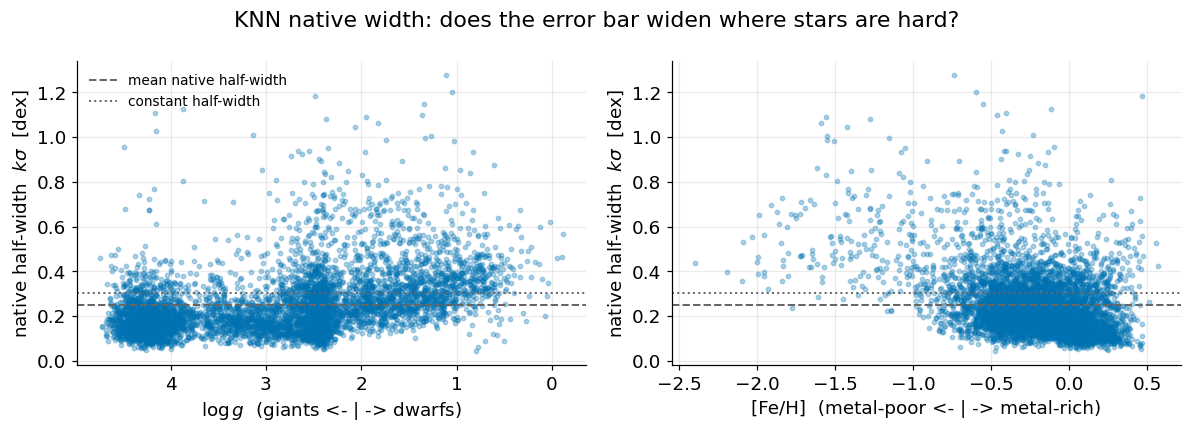

In [6]:
half_native = k * sigma_native
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(logg_test, half_native, s=8, alpha=0.3, color=COLORS["knn"])
axes[0].axhline(half_native.mean(), ls="--", color="0.4", lw=1.3, label="mean native half-width")
axes[0].axhline(k * sigma_const, ls=":", color="0.4", lw=1.3, label="constant half-width")
axes[0].set_xlabel(r"$\log g$  (giants <- | -> dwarfs)")
axes[0].set_ylabel(r"native half-width  $k\sigma$  [dex]")
axes[0].invert_xaxis(); axes[0].legend(fontsize=9)
axes[1].scatter(feh_test, half_native, s=8, alpha=0.3, color=COLORS["knn"])
axes[1].axhline(half_native.mean(), ls="--", color="0.4", lw=1.3)
axes[1].axhline(k * sigma_const, ls=":", color="0.4", lw=1.3)
axes[1].set_xlabel(r"[Fe/H]  (metal-poor <- | -> metal-rich)")
axes[1].set_ylabel(r"native half-width  $k\sigma$  [dex]")
fig.suptitle("KNN native width: does the error bar widen where stars are hard?")
fig.tight_layout(); savefig("knn_native_width_vs_logg_FeH.png"); plt.show()
# <- look for: the native widths fan UP toward low log g (giants) and low [Fe/H] (metal-poor),
#    while the constant band (dotted) is flat. That fanning is the adaptivity you just bought.

## 3 · The fudge factor — calibrate your native σ (the core step)

Your native σ gives the **shape** — *which* stars are uncertain (giants and metal-poor ones get wider
bands). But does it have the right **scale**? The neighbour scatter is a raw number; nothing forced it
to land at 90% coverage.

The fix is the same knob you practised in the common notebook, now on an *adaptive* width: multiply
every σ by a single **fudge factor `c`**, so the band becomes `prediction ± c·k·σ`. Crucially, `c`
rescales **all** stars at once — it keeps the *shape* (the giants stay relatively wider) and only fixes
the overall *scale*.

**The honest recipe (tune on cal, report on test):**

1. Compute the native σ on the **calibration** stars too (truths we're allowed to peek at).
2. **Sweep `c`** and watch calibration coverage climb through 90%.
3. Pick the `c` where it crosses the target.
4. Apply that *same* `c` to the **test** set and report coverage there — honestly.

Tuning `c` on the test set would be cheating (you'd just memorise the answer). This "tune on cal,
report on test" move is exactly the seed of conformal prediction in Notebook 4.

In [7]:
# Native sigma on the CALIBRATION stars (same recipe as the test set, different rows).
y_pred_cal = pipe.predict(sp["X_cal"])
dist_cal, idx_cal = knn.kneighbors(scaler.transform(sp["X_cal"]))
sigma_native_cal = y_train_feh[idx_cal].std(axis=1)          # (n_cal,)
print(f"calibration native sigma: median = {np.median(sigma_native_cal):.3f} dex")

# Coverage of the RAW native band (c = 1) on test, for reference.
cov_native_raw = empirical_coverage(y_test_feh,
                                    y_pred - k * sigma_native,
                                    y_pred + k * sigma_native)
print(f"native band at c = 1.0: test coverage = {cov_native_raw:.1%}   (target = {TARGET_LEVEL:.0%})")

calibration native sigma: median = 0.131 dex
native band at c = 1.0: test coverage = 89.5%   (target = 90%)


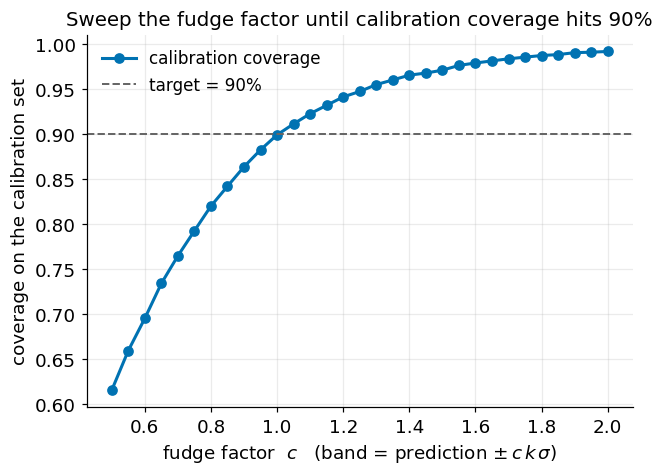

chosen c = 1.00
   calibration coverage at this c = 89.9%
   TEST coverage at this c        = 89.5%   (target = 90%)
   median width: native = 0.427 dex   vs constant = 0.604 dex


In [8]:
# Sweep the fudge factor c on the CALIBRATION set, then read coverage on TEST.
c_grid = np.linspace(0.5, 2.0, 31)
cal_cov = np.array([
    empirical_coverage(y_cal_feh, y_pred_cal - c * k * sigma_native_cal,
                                  y_pred_cal + c * k * sigma_native_cal)
    for c in c_grid])

fig, ax = plt.subplots()
ax.plot(c_grid, cal_cov, "o-", color=COLORS["knn"], label="calibration coverage")
ax.axhline(TARGET_LEVEL, ls="--", color="0.4", lw=1.3, label=f"target = {TARGET_LEVEL:.0%}")
ax.set_xlabel(r"fudge factor  $c$   (band = prediction $\pm\, c\,k\,\sigma$)")
ax.set_ylabel("coverage on the calibration set")
ax.set_title("Sweep the fudge factor until calibration coverage hits 90%")
ax.legend(); savefig("knn_fudge_sweep.png"); plt.show()

# Read off the c where the calibration curve crosses the target, then set it here:
c_fudge = 1.0    # <- your turn: change to the c that lands CALIBRATION coverage on 90% (read it off the plot)

# Apply the SAME c to the TEST set and check coverage honestly.
native_lower = y_pred - c_fudge * k * sigma_native
native_upper = y_pred + c_fudge * k * sigma_native
cov_native = empirical_coverage(y_test_feh, native_lower, native_upper)
cal_cov_at_c = empirical_coverage(y_cal_feh, y_pred_cal - c_fudge*k*sigma_native_cal,
                                             y_pred_cal + c_fudge*k*sigma_native_cal)
print(f"chosen c = {c_fudge:.2f}")
print(f"   calibration coverage at this c = {cal_cov_at_c:.1%}")
print(f"   TEST coverage at this c        = {cov_native:.1%}   (target = {TARGET_LEVEL:.0%})")
print(f"   median width: native = {np.median(native_upper-native_lower):.3f} dex   "
      f"vs constant = {2*k*sigma_const:.3f} dex")

## 4 · You fixed the average — but is it honest *everywhere*?

You just made **marginal** coverage hit 90%. Now the real test: slice the coverage by the two physical
axes and see whether the fudged native band is honest **for every kind of star**, or only on average.

Remember the headline idea from the common notebook: **marginal ≠ conditional.** A band can be 90% on
average while quietly under-covering the giants or the metal-poor stars. This is a **discovery** step —
let the plots tell you which bins break.

You'll compare three things on the same axes:

- the **constant** band (§1) — flat, blind to the hard regions,
- your **fudged native** band (§3) — adaptive, marginally calibrated,
- and you can toggle the **un-fudged** native band to see what `c` changed.

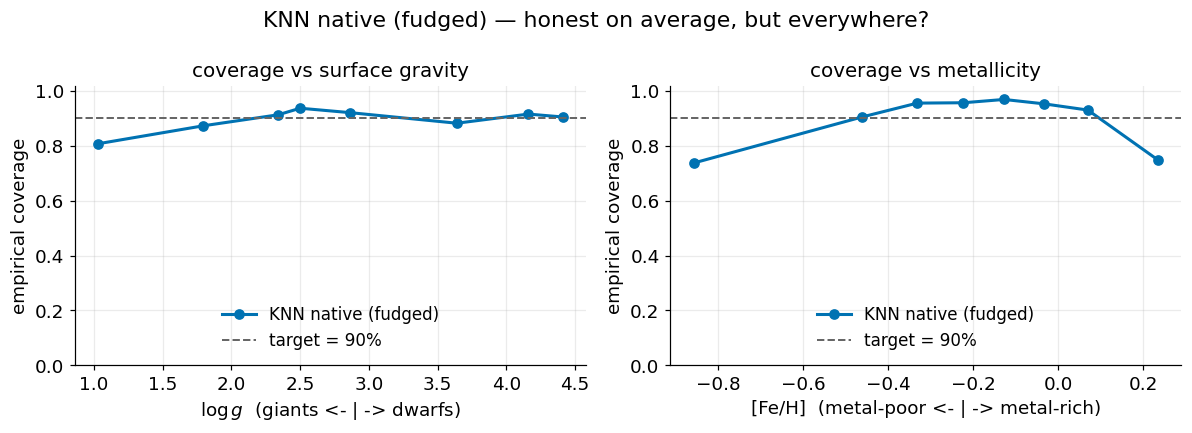

In [9]:
# Reliability of the FUDGED native interval, sliced by both physical axes.
lo_plot, hi_plot = native_lower, native_upper    # <- your turn: try (shared_lower, shared_upper)
                                                 #    to see the constant band's sag for comparison

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_reliability(y_test_feh, lo_plot, hi_plot, target=TARGET_LEVEL,
                 feature=logg_test, feature_name=r"$\log g$  (giants <- | -> dwarfs)",
                 ax=axes[0], color=COLORS["knn"], label="KNN native (fudged)")
axes[0].set_title("coverage vs surface gravity")
plot_reliability(y_test_feh, lo_plot, hi_plot, target=TARGET_LEVEL,
                 feature=feh_test, feature_name=r"[Fe/H]  (metal-poor <- | -> metal-rich)",
                 ax=axes[1], color=COLORS["knn"], label="KNN native (fudged)")
axes[1].set_title("coverage vs metallicity")
fig.suptitle("KNN native (fudged) — honest on average, but everywhere?")
fig.tight_layout(); savefig("knn_native_reliability.png"); plt.show()
# <- look for: which bins sag BELOW the 90% line? The giants (low log g)? The metal-poor (low [Fe/H])?

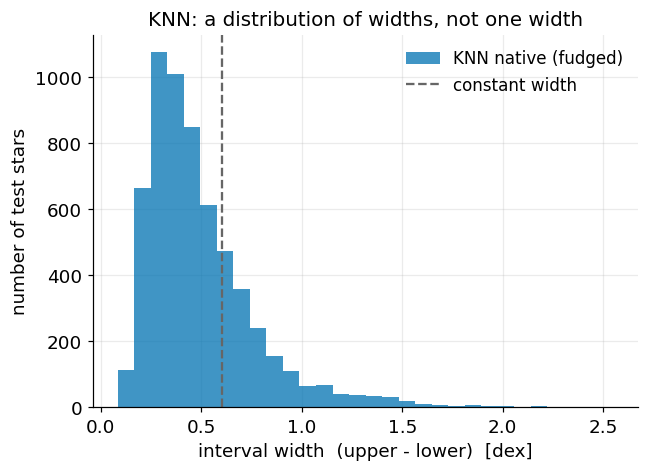

median native width = 0.427 dex   vs   constant width = 0.604 dex


In [10]:
# One more contrast: the SHAPE of the widths.  Constant band = one spike; native = a distribution.
shared_w = shared_upper - shared_lower          # constant -> a single value repeated
native_w = native_upper - native_lower          # varies per star
fig, ax = plt.subplots()
ax.hist(native_w, bins=30, alpha=0.75, color=COLORS["knn"], label="KNN native (fudged)")
ax.axvline(shared_w[0], ls="--", color="0.4", lw=1.5, label="constant width")
ax.set_xlabel("interval width  (upper - lower)  [dex]"); ax.set_ylabel("number of test stars")
ax.set_title("KNN: a distribution of widths, not one width")
ax.legend(); savefig("knn_native_width_hist.png"); plt.show()
print(f"median native width = {np.median(native_w):.3f} dex   vs   constant width = {shared_w[0]:.3f} dex")
# <- look for: the constant band is ONE spike; your native widths form a DISTRIBUTION.
#    Are the widest intervals the ones you'd WANT wide (giants, metal-poor)?

## 5 · Explore — what *flavour* of uncertainty did you capture?

No single right answer here — change things, look, and bring one annotated plot to the debrief.

1. **Aleatoric or epistemic?** Plot your per-star `sigma_native` against `[Fe/H]` *and* across the
   **Kiel plane** (`Teff` vs `log g`). Does σ grow *smoothly* toward low `[Fe/H]` (that looks
   **aleatoric** — the metal lines genuinely fade, an information floor) or *spike* in the sparse
   giant / metal-poor-halo **corner** (that looks **epistemic** — few nearby neighbours)? KNN's
   neighbour scatter captures *both*; which dominates for your stars?
2. **Where is it over/under-confident?** Find the test stars whose truth fell **outside** your
   interval. Are they clustered (giants? metal-poor?) or scattered? What would you tell someone relying
   on those predictions?
3. **(stretch) A robust scale.** Recompute the neighbour spread with the **MAD**
   (`1.4826 * median(|x − median(x)|)` along the neighbour axis) instead of `std`. Does marginal
   coverage change after re-fudging? When would a robust scale matter (heavy tails, outlier neighbours)?

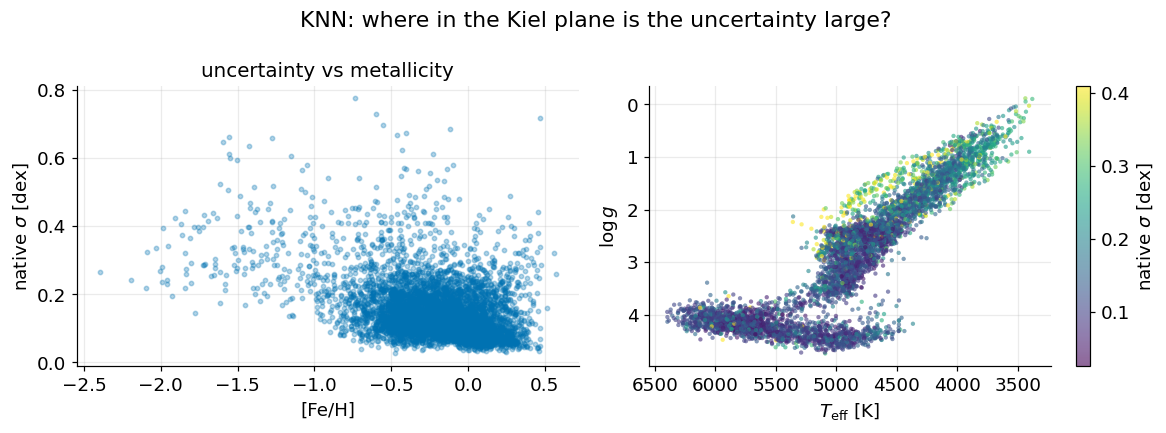

In [11]:
# A starting point for prompt 1 — extend it however you like.
Teff_test = sp["y_test"]["Teff"].to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(feh_test, sigma_native, s=8, alpha=0.3, color=COLORS["knn"])
axes[0].set_xlabel(r"[Fe/H]"); axes[0].set_ylabel(r"native $\sigma$ [dex]")
axes[0].set_title("uncertainty vs metallicity")
sc = axes[1].scatter(Teff_test, logg_test, c=sigma_native, s=8, alpha=0.6,
                     vmax=np.quantile(sigma_native, 0.98))
axes[1].set_xlabel(r"$T_\mathrm{eff}$ [K]"); axes[1].set_ylabel(r"$\log g$")
axes[1].invert_xaxis(); axes[1].invert_yaxis()
fig.colorbar(sc, ax=axes[1], label=r"native $\sigma$ [dex]")
fig.suptitle("KNN: where in the Kiel plane is the uncertainty large?")
fig.tight_layout(); savefig("knn_sigma_kiel.png"); plt.show()
# <- your turn: which corner has the biggest sigma? The giant branch? The metal-poor halo?
#    Smooth growth toward low [Fe/H] = aleatoric; a spike in the sparse corner = epistemic.

## 6 · Save your native interval for Notebook 4

Notebook 4 will **conformalize** this same KNN and compare against today's native interval, so we save
the **fudged** native interval (the one that's *yours*) in the locked schema:

`outputs/knn_native_intervals.npz` with keys `y_test_true, lower, upper, target`.

We save the §3 fudged band — not the constant baseline — because that's the model-native uncertainty
Notebook 4 puts conformal up against.

In [12]:
path = save_outputs(f"{MODEL}_native_intervals.npz",
                    y_test_true=y_test_feh,
                    lower=native_lower,
                    upper=native_upper,
                    target=TARGET_LEVEL)
print("saved ->", path)

# Sanity re-load so you SEE the contract Notebook 4 will read:
chk = load_outputs(f"{MODEL}_native_intervals.npz")
print("keys:", list(chk.keys()),
      "| coverage re-check:",
      f"{empirical_coverage(chk['y_test_true'], chk['lower'], chk['upper']):.1%}",
      "| target:", float(chk["target"]))

saved -> /mnt/c/Users/joshs/Dropbox/GitHub/utssrp-2026/outputs/knn_native_intervals.npz
keys: ['y_test_true', 'lower', 'upper', 'target'] | coverage re-check: 89.5% | target: 0.9


## Stretch 1 (optional) · Input Monte Carlo — how does error scale with *input* noise?

Everything above used uncertainty from the *neighbours*. A complementary idea propagates the
**measurement noise on the inputs** through the model: each star's 110 coefficients have known error
bars, so **perturb the inputs within those errors and re-predict many times** — the spread of the
predictions is the part of the uncertainty that comes from noisy *measurements* (a clean slice of
*aleatoric* uncertainty).

`load_input_errors()` returns the per-coefficient error array (same rows/shape as `X`). The recipe:
perturb the **raw** coefficients, re-apply the same `normalize_by_g`, predict, repeat. We run it on a
**small slice** so it stays fast.

Your turn: vary the noise multiplier and watch how the prediction scatter grows.

In [13]:
Xerr = load_input_errors()                       # per-coefficient errors, shape (N, 110), raw scale
if Xerr is None:
    print("No input errors stored for this dataset — skipping the input-MC stretch.")
else:
    rng = np.random.default_rng(0)
    SLICE = 600                                  # keep it SMALL so this is fast
    i_te = sp["idx_test"][:SLICE]                # raw-array rows for these test stars
    Xraw = X[i_te]                               # RAW coefficients (pre-normalize)
    gsel = meta["gflux"].to_numpy()[i_te]
    Eraw = Xerr[i_te]
    y_sl = y[target].to_numpy()[i_te]

    noise_mult = 1.0   # <- your turn: try 0.5, 2.0, 4.0 and watch the prediction scatter grow
    NMC = 30
    sims = np.stack([
        pipe.predict(normalize_by_g(Xraw + rng.normal(0, 1, Xraw.shape) * Eraw * noise_mult, gsel))
        for _ in range(NMC)])
    sigma_input = sims.std(axis=0)               # per-star scatter from INPUT noise alone
    print(f"input-MC at noise x{noise_mult}: median sigma_input = {np.median(sigma_input):.3f} dex "
          f"({NMC} passes on {SLICE} stars)")
    print(f"compare: neighbour-scatter median sigma on these stars = "
          f"{np.median(sigma_native[:SLICE]):.3f} dex")

input-MC at noise x1.0: median sigma_input = 0.055 dex (30 passes on 600 stars)
compare: neighbour-scatter median sigma on these stars = 0.129 dex


## Stretch 2 (optional) · Multi-label uncertainty — Teff, log g, [Fe/H] at once

KNN's native trick generalises for free to **predicting several labels jointly**: the same neighbours
carry *all* the labels, so each label gets its own per-star σ from the spread of the neighbours' values
for that label. Fit a multi-output KNN, read out a `(n_test, 3)` σ array, and you have honest error
bars on `Teff`, `log g`, and `[Fe/H]` together.

Your turn: pick the labels and read out the per-label neighbour scatter.

In [14]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

labels = ["Teff", "logg", "FeH"]   # <- your turn: try adding "alpha" or "dist"
Ytr = sp["y_train"][labels].to_numpy()

# Same KNN settings you tuned (n_neighbors=12, p=1, weights="distance"), now multi-output.
ml = make_pipeline(StandardScaler(),
                   KNeighborsRegressor(n_neighbors=12, p=1, weights="distance"))
ml.fit(sp["X_train"], Ytr)
ml_scaler = ml.named_steps["standardscaler"]; ml_knn = ml.named_steps["kneighborsregressor"]

d_ml, idx_ml = ml_knn.kneighbors(ml_scaler.transform(sp["X_test"]))
sigma_ml = Ytr[idx_ml].std(axis=1)               # (n_test, n_labels) — one sigma per label per star
print("per-star sigma array shape:", sigma_ml.shape, " (n_test, n_labels)")
for j, lab in enumerate(labels):
    print(f"  {lab:5s}: median native sigma = {np.median(sigma_ml[:, j]):.3g}")

per-star sigma array shape: (6000, 3)  (n_test, n_labels)
  Teff : median native sigma = 103
  logg : median native sigma = 0.222
  FeH  : median native sigma = 0.13


## Wrap-up · what you built, and the cliffhanger

**What you did:** read KNN's **native** per-star uncertainty out of its neighbours' scatter, tuned a
single **fudge factor `c`** on the calibration set to hit 90% on average, and then sliced the coverage
to test whether the average fix held everywhere.

**What you found:** the native band is genuinely **adaptive** — it widens for giants and metal-poor
stars, and it was nearly calibrated even before the fudge (the neighbour scatter contains the real
aleatoric floor). But after fixing the **marginal** coverage, the **conditional sag persisted**: the
luminous giants and the metal-poor stars are still under-covered. One scalar `c` can rescale every
band, but it can't fix a per-region miscalibration.

**The open problem for Notebook 4:** can we get a *guaranteed* coverage level without trusting a
Gaussian assumption — **conformal prediction** — and does it close the giant / metal-poor gap, or only
the average? *(Preview: it nails the average; the conditional gap survives. That's the poster
headline.)*

### What got saved today
- `outputs/knn_native_intervals.npz` — keys `y_test_true, lower, upper, target` (feeds Notebook 4).
- Figures in `figures/`: `knn_native_width_vs_logg_FeH.png`, `knn_fudge_sweep.png`,
  `knn_native_reliability.png`, `knn_native_width_hist.png`, `knn_sigma_kiel.png` (+ the stretch
  figures if you ran them).

## Further reading

- **scikit-learn — `KNeighborsRegressor`** (`.kneighbors` returns `(distances, indices)`; how `predict`
  averages the neighbours):
  https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html
- **Aleatoric vs. epistemic uncertainty** — Hüllermeier & Waegeman (2021), *An Introduction to Concepts
  and Methods* (open access): https://arxiv.org/abs/1910.09457
- **A Gentle Introduction to Conformal Prediction and Distribution-Free UQ** — Angelopoulos & Bates
  (2021), §1–2 define empirical coverage and the marginal-vs-conditional distinction your reliability
  plots just exposed: https://arxiv.org/abs/2107.07511
- **Calibration (statistics)** — Wikipedia, a short plain-language anchor for "does the promise hold?":
  https://en.wikipedia.org/wiki/Calibration_(statistics)
- **Laroche & Speagle (2025)** — the real-science version: Gaia's chemical information is rich for
  metal-rich disk stars and fades for the metal-poor halo, the same failure mode you found:
  https://arxiv.org/abs/2404.07316
- *What real teams use to track calibration experiments:* **MLflow** (https://mlflow.org/) and
  **Weights & Biases** (https://wandb.ai/) — a pointer, not required here.

> **Quantile-forest note (concept):** Student B's random forest has a cousin, the *quantile regression
> forest*, that predicts the 5th/95th percentiles directly (so it includes the aleatoric floor without
> a fudge factor). The package `quantile-forest` isn't on our stack — ask a TA before importing it.